In [116]:
print("Hello World!!")

Hello World!!


In [117]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt 
import seaborn as sns
import scipy.stats as st
import warnings
warnings.filterwarnings('ignore')

# Importing Data

In [118]:
df = pd.read_csv(r"/Users/developer/Documents/Current Project/Python/DevArena /DevArena-Week-7/data/uber_data.csv")
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,1,2016-03-01 00:00:00,2016-03-01 00:07:55,1,2.50,-73.976746,40.765152,1,N,-74.004265,40.746128,1,9.0,0.5,0.5,2.05,0.00,0.3,12.35
1,1,2016-03-01 00:00:00,2016-03-01 00:11:06,1,2.90,-73.983482,40.767925,1,N,-74.005943,40.733166,1,11.0,0.5,0.5,3.05,0.00,0.3,15.35
2,2,2016-03-01 00:00:00,2016-03-01 00:31:06,2,19.98,-73.782021,40.644810,1,N,-73.974541,40.675770,1,54.5,0.5,0.5,8.00,0.00,0.3,63.80
3,2,2016-03-01 00:00:00,2016-03-01 00:00:00,3,10.78,-73.863419,40.769814,1,N,-73.969650,40.757767,1,31.5,0.0,0.5,3.78,5.54,0.3,41.62
4,2,2016-03-01 00:00:00,2016-03-01 00:00:00,5,30.43,-73.971741,40.792183,3,N,-74.177170,40.695053,1,98.0,0.0,0.0,0.00,15.50,0.3,113.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1,2016-03-01 06:17:10,2016-03-01 06:22:15,1,0.50,-73.990898,40.750519,1,N,-73.998245,40.750462,2,5.0,0.0,0.5,0.00,0.00,0.3,5.80
99996,1,2016-03-01 06:17:10,2016-03-01 06:32:41,1,3.40,-74.014488,40.718296,1,N,-73.982361,40.752529,1,14.0,0.0,0.5,2.00,0.00,0.3,16.80
99997,1,2016-03-01 06:17:10,2016-03-01 06:37:23,1,9.70,-73.963379,40.774097,1,N,-73.865028,40.770512,1,29.0,0.0,0.5,8.80,5.54,0.3,44.14
99998,2,2016-03-01 06:17:10,2016-03-01 06:22:09,1,0.92,-73.984901,40.763111,1,N,-73.970695,40.759148,1,5.5,0.5,0.5,1.36,0.00,0.3,8.16


In [119]:
df.dtypes

VendorID                   int64
tpep_pickup_datetime         str
tpep_dropoff_datetime        str
passenger_count            int64
trip_distance            float64
pickup_longitude         float64
pickup_latitude          float64
RatecodeID                 int64
store_and_fwd_flag           str
dropoff_longitude        float64
dropoff_latitude         float64
payment_type               int64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
dtype: object

# Preprocessing

In [120]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

In [121]:
df['duration'] = df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
df['duration'] = df['duration'].dt.total_seconds() /60
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,duration
0,1,2016-03-01 00:00:00,2016-03-01 00:07:55,1,2.50,-73.976746,40.765152,1,N,-74.004265,40.746128,1,9.0,0.5,0.5,2.05,0.00,0.3,12.35,7.916667
1,1,2016-03-01 00:00:00,2016-03-01 00:11:06,1,2.90,-73.983482,40.767925,1,N,-74.005943,40.733166,1,11.0,0.5,0.5,3.05,0.00,0.3,15.35,11.100000
2,2,2016-03-01 00:00:00,2016-03-01 00:31:06,2,19.98,-73.782021,40.644810,1,N,-73.974541,40.675770,1,54.5,0.5,0.5,8.00,0.00,0.3,63.80,31.100000
3,2,2016-03-01 00:00:00,2016-03-01 00:00:00,3,10.78,-73.863419,40.769814,1,N,-73.969650,40.757767,1,31.5,0.0,0.5,3.78,5.54,0.3,41.62,0.000000
4,2,2016-03-01 00:00:00,2016-03-01 00:00:00,5,30.43,-73.971741,40.792183,3,N,-74.177170,40.695053,1,98.0,0.0,0.0,0.00,15.50,0.3,113.80,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1,2016-03-01 06:17:10,2016-03-01 06:22:15,1,0.50,-73.990898,40.750519,1,N,-73.998245,40.750462,2,5.0,0.0,0.5,0.00,0.00,0.3,5.80,5.083333
99996,1,2016-03-01 06:17:10,2016-03-01 06:32:41,1,3.40,-74.014488,40.718296,1,N,-73.982361,40.752529,1,14.0,0.0,0.5,2.00,0.00,0.3,16.80,15.516667
99997,1,2016-03-01 06:17:10,2016-03-01 06:37:23,1,9.70,-73.963379,40.774097,1,N,-73.865028,40.770512,1,29.0,0.0,0.5,8.80,5.54,0.3,44.14,20.216667
99998,2,2016-03-01 06:17:10,2016-03-01 06:22:09,1,0.92,-73.984901,40.763111,1,N,-73.970695,40.759148,1,5.5,0.5,0.5,1.36,0.00,0.3,8.16,4.983333


In [122]:
df_1 = df[['passenger_count', 'payment_type', 'fare_amount', 'trip_distance', 'duration']]
df_1.isnull().sum()

passenger_count    0
payment_type       0
fare_amount        0
trip_distance      0
duration           0
dtype: int64

In [123]:
df_1.dtypes

passenger_count      int64
payment_type         int64
fare_amount        float64
trip_distance      float64
duration           float64
dtype: object

In [124]:
df_1['passenger_count'].value_counts(normalize=True).sort_values()

passenger_count
0    0.00003
4    0.01894
3    0.04076
6    0.06077
5    0.08748
2    0.13709
1    0.65493
Name: proportion, dtype: float64

In [125]:
df_1['payment_type'].value_counts(normalize=True).sort_values()

payment_type
4    0.00076
3    0.00173
2    0.33203
1    0.66548
Name: proportion, dtype: float64

In [126]:
df_1 = df_1[(df_1['passenger_count'] < 6) & (df_1['payment_type'].isin([1,2]))] 
df_1

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,1,9.0,2.50,7.916667
1,1,1,11.0,2.90,11.100000
2,2,1,54.5,19.98,31.100000
3,3,1,31.5,10.78,0.000000
4,5,1,98.0,30.43,0.000000
...,...,...,...,...,...
99995,1,2,5.0,0.50,5.083333
99996,1,1,14.0,3.40,15.516667
99997,1,1,29.0,9.70,20.216667
99998,1,1,5.5,0.92,4.983333


In [127]:
df_1['payment_type'] = df_1['payment_type'].replace([1,2], ["Credit Card", "Cash"], inplace=True)
df_1

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,Credit Card,9.0,2.50,7.916667
1,1,Credit Card,11.0,2.90,11.100000
2,2,Credit Card,54.5,19.98,31.100000
3,3,Credit Card,31.5,10.78,0.000000
4,5,Credit Card,98.0,30.43,0.000000
...,...,...,...,...,...
99995,1,Cash,5.0,0.50,5.083333
99996,1,Credit Card,14.0,3.40,15.516667
99997,1,Credit Card,29.0,9.70,20.216667
99998,1,Credit Card,5.5,0.92,4.983333


In [128]:
df_1 = df_1[df_1['fare_amount'] > 0]

<Axes: >

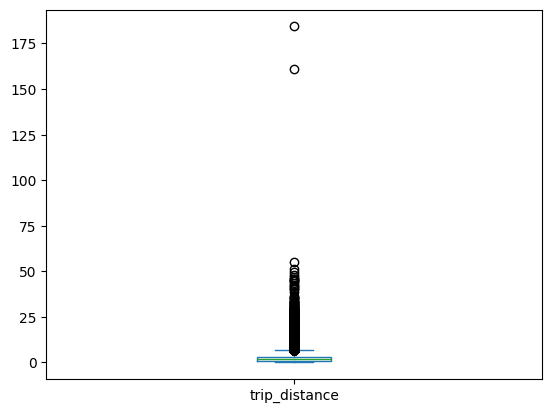

In [129]:
df_1['trip_distance'].plot(kind='box')

In [130]:
for cols in ['fare_amount', 'trip_distance', 'duration']:
    Q1 = df_1[cols].quantile(0.25)
    Q3 = df_1[cols].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR 
    upper_bound = Q3 + 1.5 * IQR 

    df_1 = df_1[(df_1[cols] <= upper_bound) & (df_1[cols] >= lower_bound)]

In [131]:
df_1

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,Credit Card,9.0,2.50,7.916667
1,1,Credit Card,11.0,2.90,11.100000
8,1,Credit Card,5.5,0.70,4.983333
10,2,Cash,4.0,0.54,2.033333
11,1,Cash,8.0,1.70,7.783333
...,...,...,...,...,...
99993,1,Cash,14.0,3.70,13.950000
99995,1,Cash,5.0,0.50,5.083333
99996,1,Credit Card,14.0,3.40,15.516667
99998,1,Credit Card,5.5,0.92,4.983333


# Statistical Description

In [132]:
df_1.describe()

,passenger_count,fare_amount,trip_distance,duration
count,76707.000000,76707.000000,76707.000000,76707.000000
mean,1.671855,9.175935,1.670542,10.777088
std,1.249177,3.805702,1.044719,6.108714
min,0.000000,0.010000,0.000000,0.000000
25%,1.000000,6.000000,0.900000,5.983333
50%,1.000000,8.500000,1.400000,9.683333
75%,2.000000,11.500000,2.190000,14.566667
max,5.000000,27.000000,5.070000,28.666667


In [133]:
df_1.dtypes

passenger_count      int64
payment_type        object
fare_amount        float64
trip_distance      float64
duration           float64
dtype: object

## Descriptive Statistics

### Mean (95% Confidence Interval)

In [134]:
z = 1.96 #-- corresponding value from z-table for alpha 0.05
def calc_mean_with_ci(cols):
    global z
    data = df_1[cols]

    average = data.mean()
    std_dev = data.std()
    m = data.mode()
    med = data.median()
    n = len(data)
    
    margin_error = z * (std_dev/ np.sqrt(n))

    upper_margin = average + margin_error
    lower_margin = average - margin_error

    print(f"Average Sales: ${average:,.0f} ± ${margin_error:,.0f} (95% CI)")
    print(f"Margin Error: {margin_error}")
    print(f"Median: {med}")
    print(f"Mode: {m}")
    print(f"Standard Deviation: {std_dev}")

In [135]:
calc_mean_with_ci('fare_amount')

Average Sales: $9 ± $0 (95% CI)
Margin Error: 0.026932296802391644
Median: 8.5
Mode: 0    6.0
Name: fare_amount, dtype: float64
Standard Deviation: 3.805702359181846


## Correlation Analysis

In [136]:
df_1_numerized = df_1

for cols in df_1_numerized.columns:
    if(df_1_numerized[cols].dtype == 'object'):
        df_1_numerized[cols]= df_1_numerized[cols].astype('category')
        df_1_numerized[cols] = df_1_numerized[cols].cat.codes

<Axes: xlabel='trip_distance', ylabel='fare_amount'>

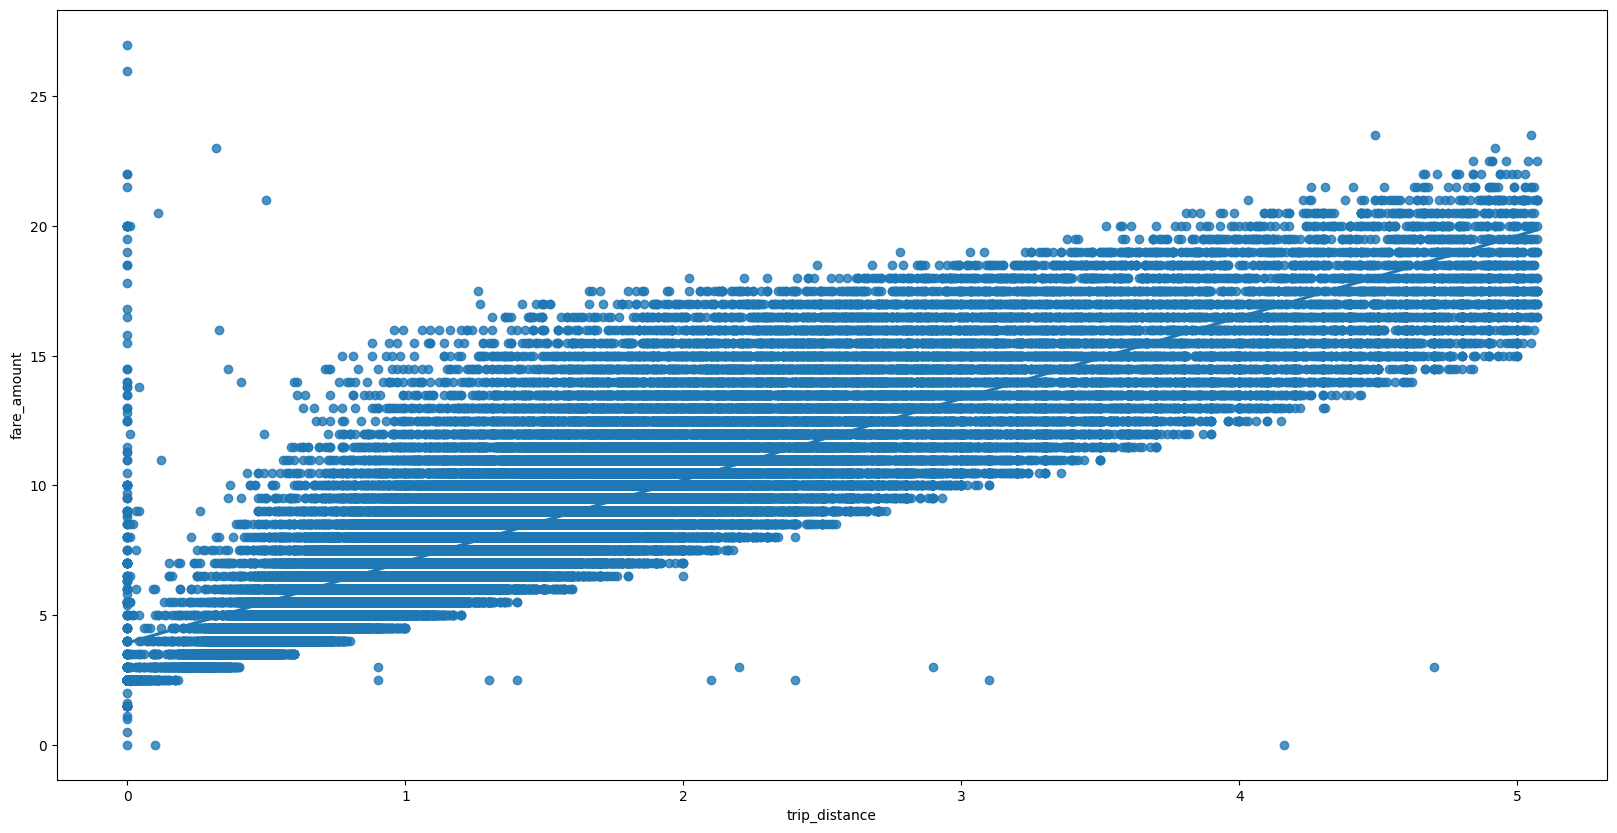

In [137]:
plt.figure(figsize=(20,10))
sns.regplot(x='trip_distance'
            , y='fare_amount'
            , data=df_1_numerized)

In [138]:
df_1_numerized.corr(method="pearson")

,passenger_count,payment_type,fare_amount,trip_distance,duration
passenger_count,1.000000,0.006902,0.014751,-0.013237,0.034466
payment_type,0.006902,1.000000,0.096608,0.081255,0.090960
fare_amount,0.014751,0.096608,1.000000,0.861884,0.930265
trip_distance,-0.013237,0.081255,0.861884,1.000000,0.649359
duration,0.034466,0.090960,0.930265,0.649359,1.000000


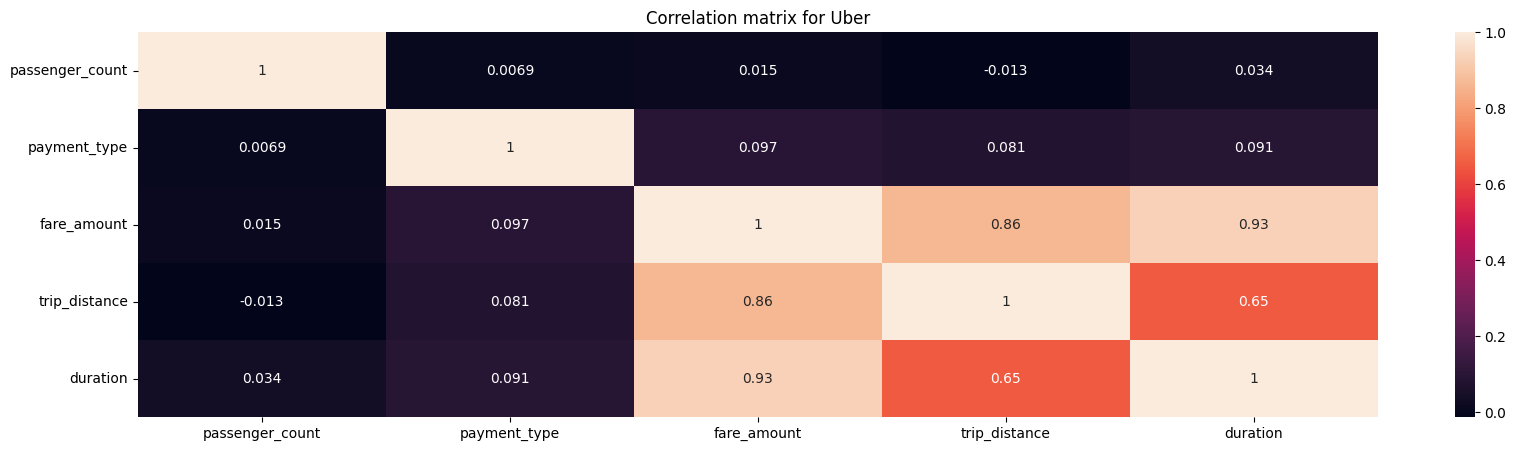

In [139]:
corr_matrix = df_1_numerized.corr(method='pearson')
plt.figure(figsize=(20,5))
sns.heatmap(data=corr_matrix, annot=True)
plt.title("Correlation matrix for Uber")
plt.show()

# Regression Analysis

In [140]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [141]:
df_1_numerized.drop(['level_0'], axis='columns', inplace=True)

KeyError: "['level_0'] not found in axis"

In [ ]:
df_1_numerized.drop(['index'], axis='columns', inplace=True)

In [ ]:
X = df_1_numerized.drop(['fare_amount'], axis='columns')
y = df_1_numerized['fare_amount']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [ ]:
reg_model = LinearRegression()

In [ ]:
reg_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
coef = reg_model.coef_
coef

array([-0.00556538,  0.02165128,  1.62536683,  0.39907439])

In [ ]:
intercept = reg_model.intercept_
print(intercept)

2.1546922152264614


In [ ]:
y_predicted = reg_model.predict(X_test)

In [ ]:
# Error Metrics
mse_val = mean_squared_error(y_test, y_predicted)
print(f"Mean Squared Error : {round(mse_val*100, 4)}")

Mean Squared Error : 29.8971


# Hypothesis Testing


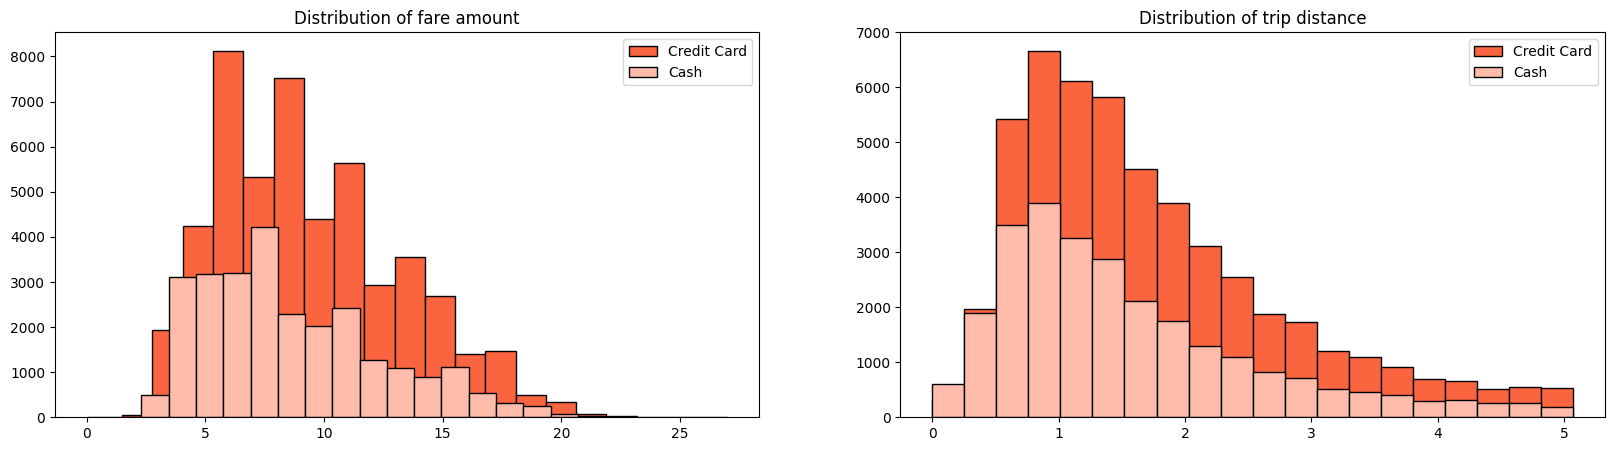

In [ ]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plt.title("Distribution of fare amount")
plt.hist(df_1[df_1['payment_type']=='Credit Card']['fare_amount'], histtype = 'barstacked', bins = 20, edgecolor = 'k', color = '#FA643F', label = 'Credit Card')
plt.hist(df_1[df_1['payment_type']=='Cash']['fare_amount'], histtype= 'barstacked', bins = 20, edgecolor = 'k', color = '#FFBCAB', label = 'Cash')
plt.legend() 
plt.subplot(1, 2, 2)
plt.title("Distribution of trip distance")
plt.hist(df_1[df_1['payment_type']=='Credit Card']['trip_distance'], histtype = 'barstacked', bins = 20, edgecolor = 'k', color = '#FA643F', label = 'Credit Card')
plt.hist(df_1[df_1['payment_type']=='Cash']['trip_distance'], histtype= 'barstacked', bins = 20, edgecolor = 'k', color = '#FFBCAB', label = 'Cash')
plt.legend() 
plt.show()

In [ ]:
df_1.groupby("payment_type").agg(
    {
        'fare_amount':['mean', 'std'] ,
        'trip_distance':['mean', 'std']
    }
)

fare_amount           trip_distance          
                    mean       std          mean       std
payment_type                                              
Cash            8.669855  3.787032      1.553695  1.035150
Credit Card     9.443035  3.788398      1.732213  1.044487

In [ ]:
pax_info = df_1.groupby(['payment_type', 'passenger_count']).agg(
    pax = ('passenger_count', 'sum')
)
pax_info['pct_total'] = round((pax_info['pax'] / pax_info['pax'].sum())*100, 2)

In [ ]:
pax_info.reset_index(inplace=True)

In [ ]:
pax_info

,payment_type,passenger_count,pax,pct_total
0,Cash,1,18449,14.39
1,Cash,2,7864,6.13
2,Cash,3,3516,2.74
3,Cash,4,2284,1.78
4,Cash,5,11875,9.26
5,Credit Card,0,0,0.00
6,Credit Card,1,34889,27.21
7,Credit Card,2,14554,11.35
8,Credit Card,3,6567,5.12
9,Credit Card,4,4060,3.17


In [ ]:
df_3 = pd.DataFrame(columns= ['payment_type', 1, 2, 3, 4, 5])
df_3['payment_type'] = ['Credit Card', 'Cash']
df_3.iloc[0,1:] = pax_info.iloc[0:5, -1]
df_3.iloc[1,1:] = pax_info.iloc[6:, -1]
df_3

,payment_type,1,2,3,4,5
0,Credit Card,14.39,6.13,2.74,1.78,9.26
1,Cash,27.21,11.35,5.12,3.17,18.86


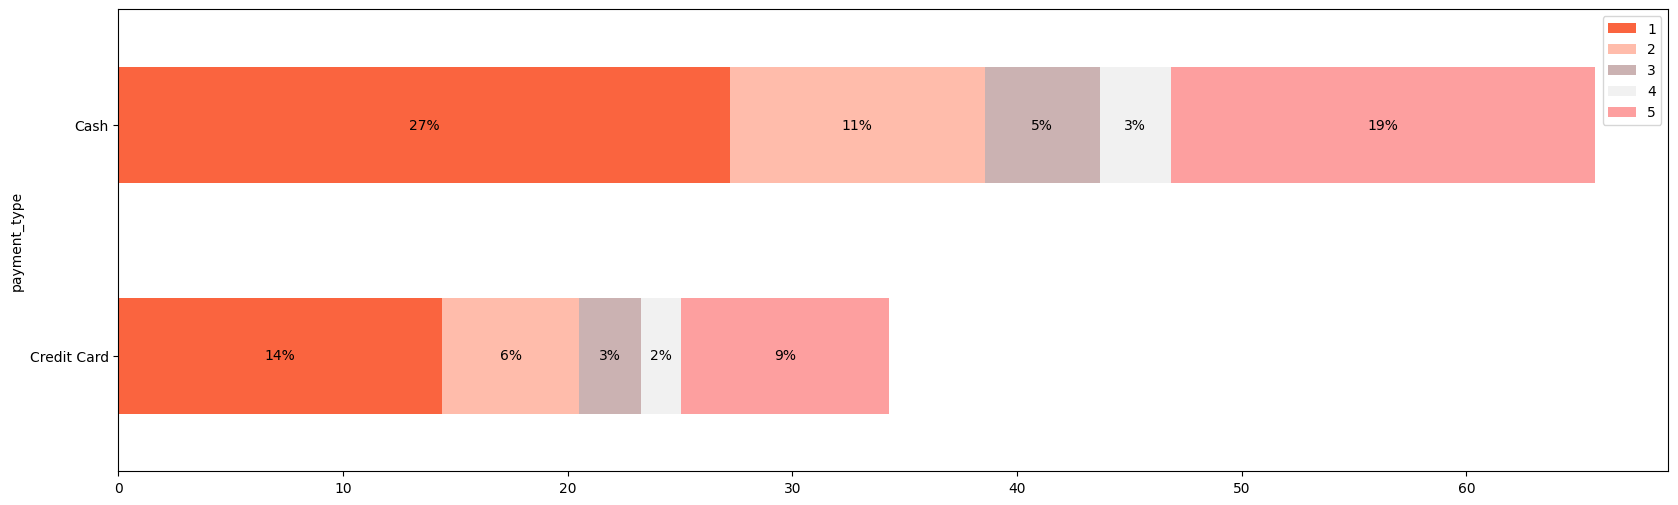

In [ ]:
fig, ax = plt.subplots(figsize=(20, 6))

df_3.plot(
    x="payment_type",
    kind="barh",
    ax=ax,
    stacked=True,
    color=['#FA643F', '#FFBCAB', '#CBB2B2', '#F1F1F1', '#FD9F9F']
)

# Add percentage text
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    
    ax.text(
        x + width / 2,
        y + height / 2,
        '{:.0f}%'.format(width),
        horizontalalignment='center',
        verticalalignment='center'
    )

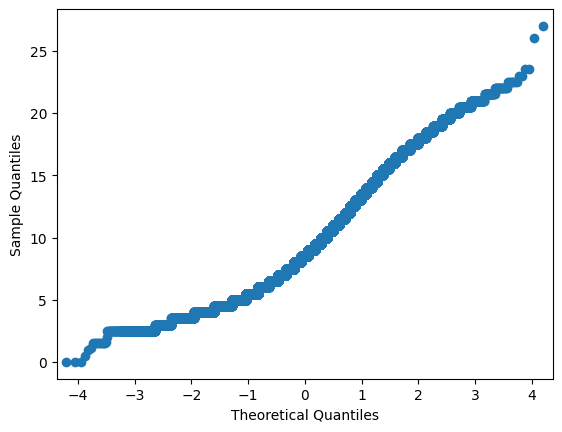

In [ ]:
import statsmodels.api as sm
sm.qqplot(df_1['fare_amount'])
plt.show()

In [ ]:
card_sample = df_1[df_1['payment_type']=='Credit Card']['fare_amount']
cash_sample = df_1[df_1['payment_type']=='Cash']['fare_amount']

In [ ]:
t_stats, p_value = st.ttest_ind(a=card_sample
                                , b=cash_sample
                                , equal_var=False)
t_stats = round(t_stats, 2)
p_value = round(p_value, 2)
print('t-statistics: ', t_stats, 'p-value', p_value)

t-statistics:  26.89 p-value 0.0
